In [5]:
import numpy as np; import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings('ignore')
import os; os.environ['LOKY_MAX_CPU_COUNT'] = '1'

In [2]:
import os
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

Current working directory: /content


In [3]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/AICode/AICode586/ML/KMeans')
current_directory = os.getcwd()
print(f"Current working directory: {current_directory}")

Current working directory: /content/drive/MyDrive/Colab Notebooks/AICode/AICode586/ML/KMeans


In [6]:
X = pd.read_csv('carprices_dataset.csv');
X.sample(2)

,enginesize,horsepower,citympg,highwaympg
32,79,60,38,42
14,164,121,20,25


In [7]:
X.shape

(205, 4)

In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   enginesize  205 non-null    int64
 1   horsepower  205 non-null    int64
 2   citympg     205 non-null    int64
 3   highwaympg  205 non-null    int64
dtypes: int64(4)
memory usage: 6.5 KB


In [9]:
X.describe()

,enginesize,horsepower,citympg,highwaympg
count,205.000000,205.000000,205.000000,205.000000
mean,126.907317,104.117073,25.219512,30.751220
std,41.642693,39.544167,6.542142,6.886443
min,61.000000,48.000000,13.000000,16.000000
25%,97.000000,70.000000,19.000000,25.000000
50%,120.000000,95.000000,24.000000,30.000000
75%,141.000000,116.000000,30.000000,34.000000
max,326.000000,288.000000,49.000000,54.000000


# Task 1
### Feature Scaling
- Scale all features using `StandardScaler()` from `sklearn.preprocessing`

In [10]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('First 5 rows of scaled data:')
display(X_scaled.head())

First 5 rows of scaled data:


,enginesize,horsepower,citympg,highwaympg
0,0.074449,0.174483,-0.646553,-0.546059
1,0.074449,0.174483,-0.646553,-0.546059
2,0.604046,1.264536,-0.953012,-0.691627
3,-0.431076,-0.053668,-0.186865,-0.109354
4,0.218885,0.275883,-1.106241,-1.273900


In [16]:
print('Checking for clusters of size 3 for K from 2 to 10:')
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='random', random_state=9001, n_init=1)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    cluster_sizes = pd.Series(labels).value_counts()

    if 3 in cluster_sizes.values:
        print(f"For K={k}, a cluster of size 3 exists. Cluster sizes: {cluster_sizes.to_dict()}")
    else:
        print(f"For K={k}, no cluster of size 3. Cluster sizes: {cluster_sizes.to_dict()}")

Checking for clusters of size 3 for K from 2 to 10:
For K=2, no cluster of size 3. Cluster sizes: {0: 117, 1: 88}
For K=3, no cluster of size 3. Cluster sizes: {2: 102, 1: 85, 0: 18}
For K=4, a cluster of size 3 exists. Cluster sizes: {3: 100, 1: 85, 2: 17, 0: 3}
For K=5, a cluster of size 3 exists. Cluster sizes: {1: 86, 3: 55, 4: 46, 2: 15, 0: 3}
For K=6, a cluster of size 3 exists. Cluster sizes: {4: 69, 1: 58, 3: 45, 5: 15, 2: 15, 0: 3}
For K=7, a cluster of size 3 exists. Cluster sizes: {1: 49, 4: 45, 3: 45, 5: 33, 6: 15, 2: 15, 0: 3}
For K=8, a cluster of size 3 exists. Cluster sizes: {1: 47, 4: 45, 3: 34, 5: 33, 6: 15, 2: 14, 7: 14, 0: 3}
For K=9, a cluster of size 3 exists. Cluster sizes: {4: 46, 8: 40, 5: 27, 1: 26, 3: 19, 7: 15, 6: 15, 2: 14, 0: 3}
For K=10, a cluster of size 3 exists. Cluster sizes: {4: 46, 8: 40, 5: 27, 1: 26, 3: 18, 6: 15, 9: 14, 2: 14, 0: 3, 7: 2}


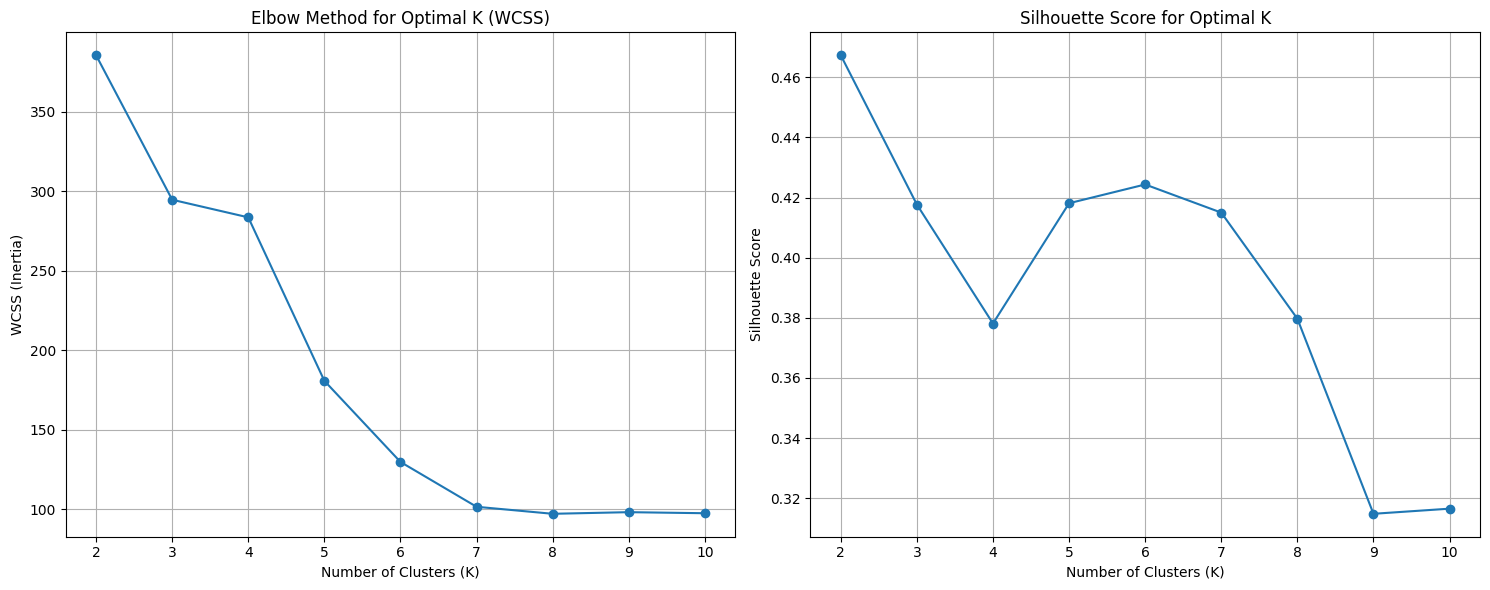

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

k_values = range(2, 11)

plt.figure(figsize=(15, 6))

# Plot for WCSS (Inertia)
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(k_values, wcss, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K (WCSS)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_values)
plt.grid(True)

# Plot for Silhouette Scores
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.title('Silhouette Score for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()

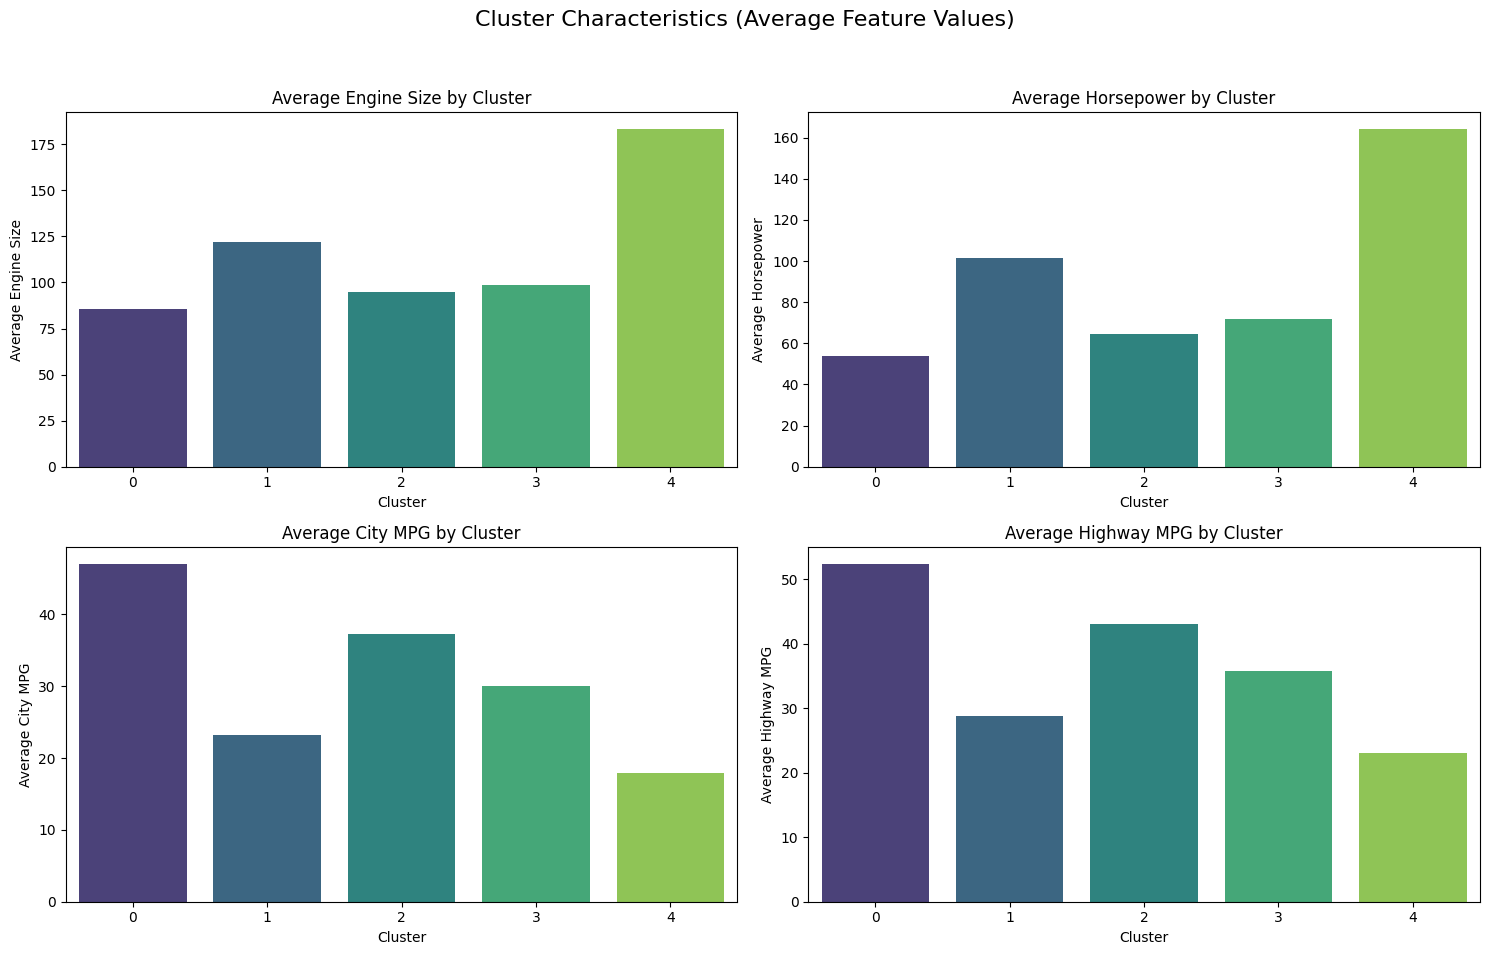

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Cluster Characteristics (Average Feature Values)', fontsize=16)

# Plot enginesize
sns.barplot(x=cluster_means.index, y='enginesize', data=cluster_means, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Average Engine Size by Cluster')
axes[0, 0].set_xlabel('Cluster')
axes[0, 0].set_ylabel('Average Engine Size')

# Plot horsepower
sns.barplot(x=cluster_means.index, y='horsepower', data=cluster_means, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Average Horsepower by Cluster')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Average Horsepower')

# Plot citympg
sns.barplot(x=cluster_means.index, y='citympg', data=cluster_means, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Average City MPG by Cluster')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Average City MPG')

# Plot highwaympg
sns.barplot(x=cluster_means.index, y='highwaympg', data=cluster_means, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Average Highway MPG by Cluster')
axes[1, 1].set_xlabel('Cluster')
axes[1, 1].set_ylabel('Average Highway MPG')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [13]:
X_clustered = X.copy()
X_clustered['Cluster'] = clusters

cluster_means = X_clustered.groupby('Cluster').mean()

print('Average feature values for each cluster:')
display(cluster_means)

Average feature values for each cluster:


,enginesize,horsepower,citympg,highwaympg
Cluster,,,,
0,85.333333,53.666667,47.000000,52.333333
1,122.000000,101.279070,23.220930,28.720930
2,94.933333,64.533333,37.266667,43.066667
3,98.527273,71.963636,29.981818,35.836364
4,183.152174,164.065217,17.913043,23.043478


By examining the average values for `enginesize`, `horsepower`, `citympg`, and `highwaympg` across the 5 clusters, we can infer the typical characteristics of cars within each group. For instance, some clusters might represent high-performance, low-mileage vehicles, while others could represent more economical or mid-range cars. This analysis helps in understanding the segmentation performed by K-Means.

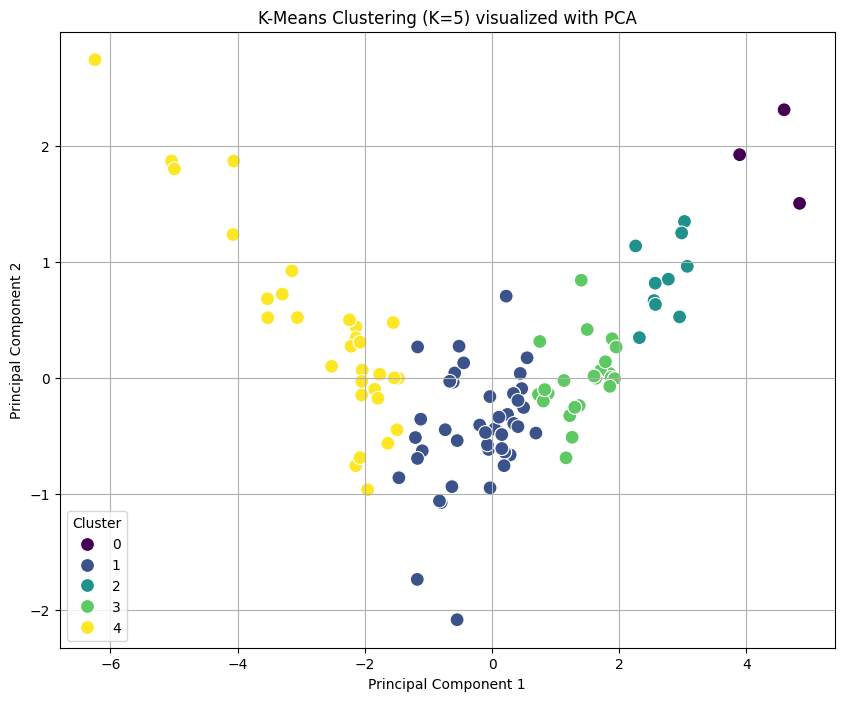

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply K-Means with K=5
kmeans = KMeans(n_clusters=5, init='random', random_state=9001, n_init=1)
clusters = kmeans.fit_predict(X_scaled)

# Reduce dimensionality to 2 for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    legend='full',
    s=100
)
plt.title('K-Means Clustering (K=5) visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [11]:
wcss = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='random', random_state=9001, n_init=1)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

    # Calculate Silhouette Score
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)

# Print the results
print('WCSS (Inertia) for K from 2 to 10:')
for i, score in enumerate(wcss):
    print(f'K={i+2}: {score:.2f}')

print('\nSilhouette Scores for K from 2 to 10:')
for i, score in enumerate(silhouette_scores):
    print(f'K={i+2}: {score:.2f}')

WCSS (Inertia) for K from 2 to 10:
K=2: 385.55
K=3: 294.68
K=4: 283.59
K=5: 180.76
K=6: 129.75
K=7: 101.55
K=8: 97.14
K=9: 98.17
K=10: 97.50

Silhouette Scores for K from 2 to 10:
K=2: 0.47
K=3: 0.42
K=4: 0.38
K=5: 0.42
K=6: 0.42
K=7: 0.41
K=8: 0.38
K=9: 0.31
K=10: 0.32


# Task 2
### Clustering for Various K
- Apply K-means clustering on the sclaed data using `KMeans()` from `sklearn.cluster` with `init = 'random'`, `random_state = 9001`,on the scaled data using random initialisation, `random_state = 9001`, and `n_init = 1`
- Compute and analyse the inertia or WCSS and the Silhouette score for values of K from 2 to 10

In [ ]:
##### CODE HERE #####